In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [5]:
diabetes_data = pd.read_excel('Diabetes_Data.xlsx')

print(f"Shape: {diabetes_data.shape}")
print(f"\nColumns: {diabetes_data.columns.tolist()}")
print(f"\nFirst 5 rows:\n{diabetes_data.head()}")


Shape: (442, 11)

Columns: ['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']

First 5 rows:
   AGE  SEX   BMI     BP   S1     S2    S3   S4      S5  S6    Y
0   59    2  32.1  101.0  157   93.2  38.0  4.0  4.8598  87  151
1   48    1  21.6   87.0  183  103.2  70.0  3.0  3.8918  69   75
2   72    2  30.5   93.0  156   93.6  41.0  4.0  4.6728  85  141
3   24    1  25.3   84.0  198  131.4  40.0  5.0  4.8903  89  206
4   50    1  23.0  101.0  192  125.4  52.0  4.0  4.2905  80  135


QUESTION 1.1: CORRELATION ANALYSIS


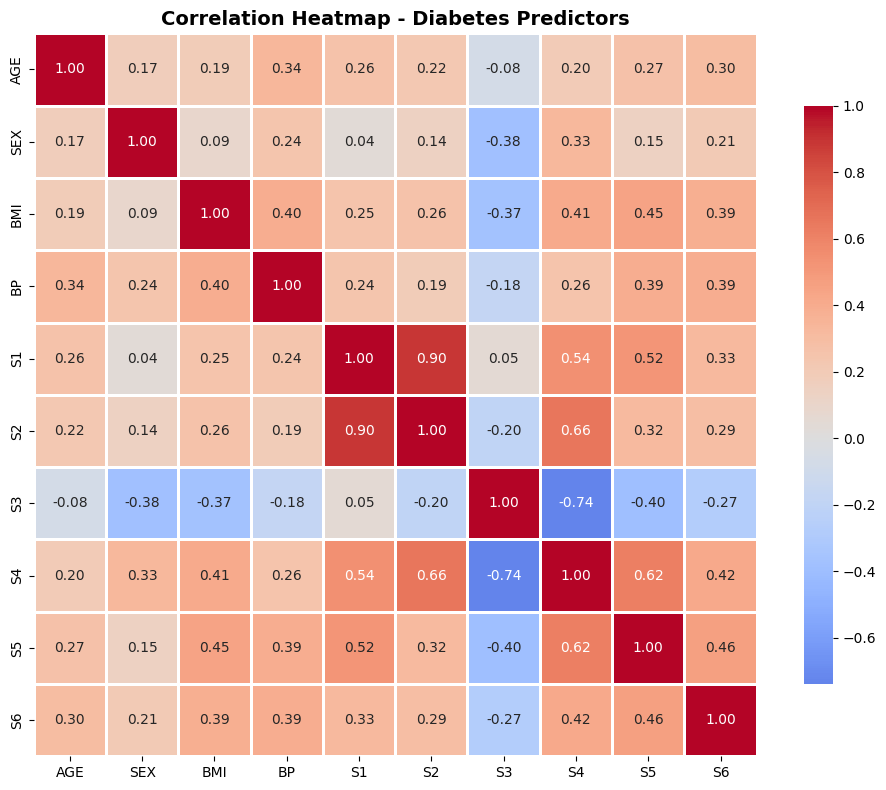


Correlation Matrix:
          AGE       SEX       BMI        BP        S1        S2        S3  \
AGE  1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
SEX  0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
BMI  0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
BP   0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
S1   0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
S2   0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
S3  -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
S4   0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
S5   0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
S6   0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   

           S4        S5        S6  
AGE  0.203841  0.270774  0.301731  
SEX  0.332115  0.149916  0.208133  
BMI  0.413807  0.446157

In [6]:
print("QUESTION 1.1: CORRELATION ANALYSIS")

predictors = diabetes_data.drop('Y', axis=1)
corr_mat = predictors.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Diabetes Predictors', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nCorrelation Matrix:\n{corr_mat}")

In [8]:
print("1.3: FULL MULTIVARIATE LINEAR MODEL")

X = diabetes_data.drop('Y', axis=1)
y = diabetes_data['Y']
X_const = sm.add_constant(X)

ols_model = sm.OLS(y, X_const).fit()

y_fitted = ols_model.predict(X_const)
mse_full = mean_squared_error(y, y_fitted)
r2_full = r2_score(y, y_fitted)
n_obs = len(y)
n_pred = X.shape[1]
adj_r2_full = 1 - (1 - r2_full) * (n_obs - 1) / (n_obs - n_pred - 1)

print(f"\nMODEL PERFORMANCE:")
print(f"   • Mean Squared Error: {mse_full:.2f}")
print(f"   • R²: {r2_full:.4f}")
print(f"   • Adjusted R²: {adj_r2_full:.4f}")

print("FULL MODEL SUMMARY")
print(ols_model.summary())

print("VARIABLE SIGNIFICANCE (α = 0.05)")

sig_list = []
insig_list = []

for variable in X.columns:
    p_val = ols_model.pvalues[variable]
    beta = ols_model.params[variable]
    
    if p_val < 0.05:
        sig_list.append(variable)
        print(f" {variable:6s}: p={p_val:.4f}, β={beta:7.2f} [SIGNIFICANT]")
    else:
        insig_list.append(variable)
        print(f" {variable:6s}: p={p_val:.4f}, β={beta:7.2f} [NOT SIGNIFICANT]")

print(f"\nSummary: {len(sig_list)}/{len(X.columns)} variables significant")
print(f"Insignificant variables: {insig_list if insig_list else 'None'}")

1.3: FULL MULTIVARIATE LINEAR MODEL

MODEL PERFORMANCE:
   • Mean Squared Error: 2859.70
   • R²: 0.5177
   • Adjusted R²: 0.5066
FULL MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        17:55:13   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [

In [9]:
def stepwise_forward(X_data, y_data, alpha=0.05, verbose=True):
    available = list(X_data.columns)
    selected = []
    
    if verbose:
        print("\nFORWARD STEPWISE PROCEDURE")
        print("="*70)
    
    iteration = 0
    while True:
        iteration += 1
        remaining = list(set(available) - set(selected))
        
        if not remaining:
            break
        
        best_p = 1.0
        best_var = None
        
        if verbose:
            print(f"\nIteration {iteration}:")
            print(f"  Current model: {selected if selected else 'intercept only'}")
            print(f"  Candidates tested: {len(remaining)}")
        
        for candidate in remaining:
            test_vars = selected + [candidate]
            X_temp = sm.add_constant(X_data[test_vars])
            temp_model = sm.OLS(y_data, X_temp).fit()
            p_value = temp_model.pvalues[candidate]
            
            if verbose:
                status = "✓" if p_value < alpha else " "
                print(f"    [{status}] {candidate}: p = {p_value:.4f}")
            
            if p_value < best_p:
                best_p = p_value
                best_var = candidate
        
        if best_p < alpha:
            selected.append(best_var)
            if verbose:
                print(f"  → INCLUDE {best_var} (p = {best_p:.4f})")
        else:
            if verbose:
                print(f"  → STOP: Best p-value = {best_p:.4f} (threshold = {alpha})")
            break
    
    if selected:
        X_final = sm.add_constant(X_data[selected])
        final_model = sm.OLS(y_data, X_final).fit()
    else:
        X_final = sm.add_constant(pd.DataFrame(np.ones(len(y_data))))
        final_model = sm.OLS(y_data, X_final).fit()
    
    return selected, final_model


In [11]:
print("1.5: STEPWISE FORWARD SELECTION APPLICATION")
selected_features, stepwise_fit = stepwise_forward(X, y, alpha=0.05)
print("STEPWISE SELECTION RESULTS")
print(f"\nSelected features: {selected_features}")
print(f"Number selected: {len(selected_features)}")

1.5: STEPWISE FORWARD SELECTION APPLICATION

FORWARD STEPWISE PROCEDURE

Iteration 1:
  Current model: intercept only
  Candidates tested: 10
    [✓] S6: p = 0.0000
    [✓] BMI: p = 0.0000
    [✓] AGE: p = 0.0001
    [✓] S4: p = 0.0000
    [✓] S3: p = 0.0000
    [✓] BP: p = 0.0000
    [✓] S2: p = 0.0002
    [ ] SEX: p = 0.3664
    [✓] S1: p = 0.0000
    [✓] S5: p = 0.0000
  → INCLUDE BMI (p = 0.0000)

Iteration 2:
  Current model: ['BMI']
  Candidates tested: 9
    [✓] S6: p = 0.0000
    [✓] AGE: p = 0.0364
    [✓] S4: p = 0.0000
    [✓] S3: p = 0.0000
    [✓] BP: p = 0.0000
    [ ] S2: p = 0.5758
    [ ] SEX: p = 0.8226
    [ ] S1: p = 0.0796
    [✓] S5: p = 0.0000
  → INCLUDE S5 (p = 0.0000)

Iteration 3:
  Current model: ['BMI', 'S5']
  Candidates tested: 8
    [ ] S6: p = 0.1468
    [ ] AGE: p = 0.8158
    [ ] S4: p = 0.3915
    [✓] S3: p = 0.0038
    [✓] BP: p = 0.0000
    [ ] S2: p = 0.0904
    [ ] SEX: p = 0.1444
    [✓] S1: p = 0.0033
  → INCLUDE BP (p = 0.0000)

Iteration 4:
 

In [12]:
if selected_features:
    X_step = sm.add_constant(X[selected_features])
    y_step_fitted = stepwise_fit.predict(X_step)
    mse_step = mean_squared_error(y, y_step_fitted)
    r2_step = r2_score(y, y_step_fitted)
    n_step = len(selected_features)
    adj_r2_step = 1 - (1 - r2_step) * (n_obs - 1) / (n_obs - n_step - 1)
    
    print(f"\nSTEPWISE MODEL METRICS:")
    print(f"   • MSE: {mse_step:.2f}")
    print(f"   • R²: {r2_step:.4f}")
    print(f"   • Adjusted R²: {adj_r2_step:.4f}")
    
    print("STEPWISE MODEL DETAILS")
    print(stepwise_fit.summary())
    
    print("MODEL COMPARISON")

    
    print(f"\n{'Metric':<25} {'Full Model':>15} {'Stepwise':>15} {'Change':>15}")
    print(f"{'Predictors':<25} {n_pred:>15} {n_step:>15} {n_step-n_pred:>15}")
    print(f"{'MSE':<25} {mse_full:>15.2f} {mse_step:>15.2f} {mse_step-mse_full:>15.2f}")
    print(f"{'R²':<25} {r2_full:>15.4f} {r2_step:>15.4f} {r2_step-r2_full:>15.4f}")
    print(f"{'Adj R²':<25} {adj_r2_full:>15.4f} {adj_r2_step:>15.4f} {adj_r2_step-adj_r2_full:>15.4f}")
    
    reduction = ((n_pred - n_step) / n_pred) * 100
    print(f"\n   • Dimensionality reduction: {reduction:.1f}%")
    print(f"   • Variables removed: {n_pred - n_step}")
    
    if adj_r2_step >= adj_r2_full:
        print(f"   • Result: Improved parsimony without sacrificing fit ")
    else:
        print(f"   • Result: Trade-off between complexity and fit")


STEPWISE MODEL METRICS:
   • MSE: 2876.68
   • R²: 0.5149
   • Adjusted R²: 0.5082
STEPWISE MODEL DETAILS
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     76.95
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           3.01e-65
Time:                        17:59:01   Log-Likelihood:                -2387.3
No. Observations:                 442   AIC:                             4789.
Df Residuals:                     435   BIC:                             4817.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [14]:
titanic_df = pd.read_csv('titanic3.csv')

print(f"Dataset Shape: {titanic_df.shape}")
print(f"\nColumns: {titanic_df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{titanic_df.head()}")
print(f"\nData Info:\n{titanic_df.info()}")
print(f"\nMissing Values:\n{titanic_df.isnull().sum()}")

Dataset Shape: (1309, 14)

Columns: ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

First 5 rows:
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500 

In [16]:
print("2.2: OVERALL SURVIVAL PROBABILITY")

total_passengers = len(titanic_df)
total_survived = titanic_df['survived'].sum()
survival_prob = total_survived / total_passengers

print(f"\nTotal Passengers: {total_passengers}")
print(f"Total Survived: {total_survived}")
print(f"Total Died: {total_passengers - total_survived}")
print(f"\nOverall Survival Probability: {survival_prob:.4f} ({survival_prob*100:.2f}%)")
print(f"Overall Death Probability: {1-survival_prob:.4f} ({(1-survival_prob)*100:.2f}%)")


2.2: OVERALL SURVIVAL PROBABILITY

Total Passengers: 1309
Total Survived: 500
Total Died: 809

Overall Survival Probability: 0.3820 (38.20%)
Overall Death Probability: 0.6180 (61.80%)


In [18]:
print("2.3: SURVIVAL PROBABILITIES BY CLASS, SEX, AGE")

print("\nSURVIVAL BY PASSENGER CLASS:")
class_survival = titanic_df.groupby('pclass')['survived'].agg(['sum', 'count', 'mean'])
class_survival.columns = ['Survived', 'Total', 'Survival_Rate']
class_survival['Died'] = class_survival['Total'] - class_survival['Survived']
print(class_survival)

print("\n\nSURVIVAL BY SEX:")
sex_survival = titanic_df.groupby('sex')['survived'].agg(['sum', 'count', 'mean'])
sex_survival.columns = ['Survived', 'Total', 'Survival_Rate']
sex_survival['Died'] = sex_survival['Total'] - sex_survival['Survived']
print(sex_survival)

print("\n\nSURVIVAL BY CLASS AND SEX:")
class_sex_survival = titanic_df.groupby(['pclass', 'sex'])['survived'].agg(['sum', 'count', 'mean'])
class_sex_survival.columns = ['Survived', 'Total', 'Survival_Rate']
print(class_sex_survival)

titanic_df['age_group'] = pd.cut(titanic_df['age'], 
                                  bins=[0, 12, 18, 35, 60, 100],
                                  labels=['Child (0-12)', 'Teen (13-18)', 
                                         'Adult (19-35)', 'Middle (36-60)', 
                                         'Senior (60+)'])

print("\n\nSURVIVAL BY AGE GROUP:")
age_survival = titanic_df.groupby('age_group', observed=True)['survived'].agg(['sum', 'count', 'mean'])
age_survival.columns = ['Survived', 'Total', 'Survival_Rate']
print(age_survival)

print("\n\nCOMPREHENSIVE TABLE (Class x Sex x Age):")
comprehensive = titanic_df.groupby(['pclass', 'sex', 'age_group'], observed=True)['survived'].agg(['sum', 'count', 'mean'])
comprehensive.columns = ['Survived', 'Total', 'Survival_Rate']
print(comprehensive)

print("\n\nAGE STATISTICS BY SURVIVAL:")
print(titanic_df.groupby('survived')['age'].describe())


2.3: SURVIVAL PROBABILITIES BY CLASS, SEX, AGE

SURVIVAL BY PASSENGER CLASS:
        Survived  Total  Survival_Rate  Died
pclass                                      
1            200    323       0.619195   123
2            119    277       0.429603   158
3            181    709       0.255289   528


SURVIVAL BY SEX:
        Survived  Total  Survival_Rate  Died
sex                                         
female       339    466       0.727468   127
male         161    843       0.190985   682


SURVIVAL BY CLASS AND SEX:
               Survived  Total  Survival_Rate
pclass sex                                   
1      female       139    144       0.965278
       male          61    179       0.340782
2      female        94    106       0.886792
       male          25    171       0.146199
3      female       106    216       0.490741
       male          75    493       0.152130


SURVIVAL BY AGE GROUP:
                Survived  Total  Survival_Rate
age_group                     

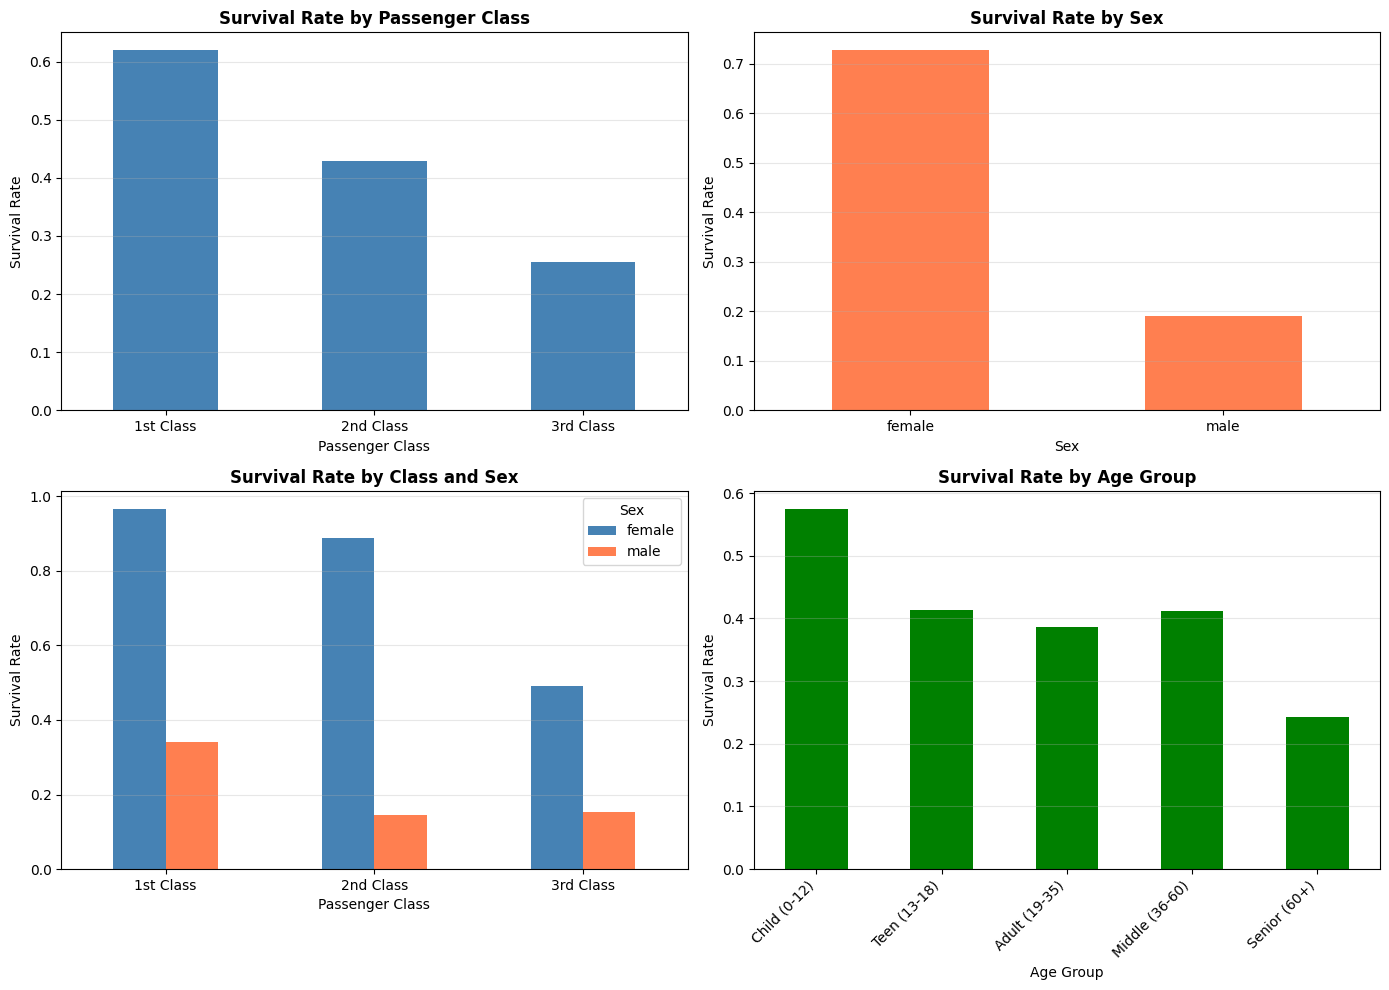

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

class_survival['Survival_Rate'].plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0,0].set_xlabel('Passenger Class')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[0,0].grid(axis='y', alpha=0.3)

sex_survival['Survival_Rate'].plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Survival Rate by Sex', fontweight='bold')
axes[0,1].set_xlabel('Sex')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_xticklabels(sex_survival.index, rotation=0)
axes[0,1].grid(axis='y', alpha=0.3)

class_sex_pivot = titanic_df.pivot_table(values='survived', index='pclass', 
                                          columns='sex', aggfunc='mean')
class_sex_pivot.plot(kind='bar', ax=axes[1,0], color=['steelblue', 'coral'])
axes[1,0].set_title('Survival Rate by Class and Sex', fontweight='bold')
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Survival Rate')
axes[1,0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[1,0].legend(title='Sex')
axes[1,0].grid(axis='y', alpha=0.3)

age_survival['Survival_Rate'].plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Survival Rate by Age Group', fontweight='bold')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Survival Rate')
axes[1,1].set_xticklabels(age_survival.index, rotation=45, ha='right')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print(" 2.4: LOGISTIC REGRESSION MODEL")
print("="*70)

titanic_model = titanic_df[['survived', 'pclass', 'sex', 'age']].copy()

print(f"\nMissing values before cleaning:\n{titanic_model.isnull().sum()}")

titanic_model = titanic_model.dropna()

print(f"\nDataset size after removing missing: {len(titanic_model)} rows")

titanic_model['sex_numeric'] = (titanic_model['sex'] == 'male').astype(int)

print(f"\nSex encoding: female=0, male=1")
print(titanic_model[['sex', 'sex_numeric']].drop_duplicates())

X = titanic_model[['pclass', 'sex_numeric', 'age']]
y = titanic_model['survived']

print(f"\nPredictors (X):\n{X.head()}")
print(f"\nTarget (y):\n{y.head()}")

 2.4: LOGISTIC REGRESSION MODEL

Missing values before cleaning:
survived      0
pclass        0
sex           0
age         263
dtype: int64

Dataset size after removing missing: 1046 rows

Sex encoding: female=0, male=1
      sex  sex_numeric
0  female            0
1    male            1

Predictors (X):
   pclass  sex_numeric    age
0       1            0  29.00
1       1            1   0.92
2       1            0   2.00
3       1            1  30.00
4       1            0  25.00

Target (y):
0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: int64


In [21]:
print("BUILDING LOGISTIC REGRESSION MODEL")

X_with_const = sm.add_constant(X)
logit_model = sm.Logit(y, X_with_const).fit()

print("\nLOGISTIC REGRESSION MODEL SUMMARY:")
print(logit_model.summary())


BUILDING LOGISTIC REGRESSION MODEL
Optimization terminated successfully.
         Current function value: 0.469897
         Iterations 6

LOGISTIC REGRESSION MODEL SUMMARY:
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                 1046
Model:                          Logit   Df Residuals:                     1042
Method:                           MLE   Df Model:                            3
Date:                Sun, 04 Jan 2026   Pseudo R-squ.:                  0.3051
Time:                        18:20:29   Log-Likelihood:                -491.51
converged:                       True   LL-Null:                       -707.31
Covariance Type:            nonrobust   LLR p-value:                 3.167e-93
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.5893      0.406  

In [ ]:
print("PARAMETER ESTIMATES AND STATISTICAL SIGNIFICANCE")

params_df = pd.DataFrame({
    'Coefficient': logit_model.params,
    'Std_Error': logit_model.bse,
    'z_value': logit_model.tvalues,
    'p_value': logit_model.pvalues,
    'Odds_Ratio': np.exp(logit_model.params)
})

print("\nPARAMETER ESTIMATES:")
print("-"*70)
print(params_df)

print("\n\n95% CONFIDENCE INTERVALS:")
print("-"*70)
conf_int = logit_model.conf_int()
conf_int.columns = ['Lower_CI', 'Upper_CI']
conf_int['Odds_Ratio_Lower'] = np.exp(conf_int['Lower_CI'])
conf_int['Odds_Ratio_Upper'] = np.exp(conf_int['Upper_CI'])
print(conf_int)

print("STATISTICAL SIGNIFICANCE (α = 0.05)")
print("="*70)

for var in params_df.index:
    coef = params_df.loc[var, 'Coefficient']
    pval = params_df.loc[var, 'p_value']
    odds = params_df.loc[var, 'Odds_Ratio']
    
    if pval < 0.05:
        significance = "SIGNIFICANT "
    else:
        significance = "NOT SIGNIFICANT "
    
    print(f"\n{var}:")
    print(f"  Coefficient (β): {coef:.4f}")
    print(f"  P-value: {pval:.4f} - {significance}")
    print(f"  Odds Ratio: {odds:.4f}")
    
    if var != 'const' and pval < 0.05:
        if coef > 0:
            print(f"  Interpretation: Increases odds of survival by factor of {odds:.3f}")
        else:
            print(f"  Interpretation: Decreases odds of survival by factor of {odds:.3f}")


PARAMETER ESTIMATES AND STATISTICAL SIGNIFICANCE

PARAMETER ESTIMATES:
----------------------------------------------------------------------
             Coefficient  Std_Error    z_value       p_value  Odds_Ratio
const           4.589269   0.405741  11.310829  1.159888e-29   98.422411
pclass         -1.133244   0.111734 -10.142325  3.584638e-24    0.321987
sex_numeric    -2.497377   0.166127 -15.032967  4.465515e-51    0.082301
age            -0.033885   0.006281  -5.395117  6.847893e-08    0.966683


95% CONFIDENCE INTERVALS:
----------------------------------------------------------------------
             Lower_CI  Upper_CI  Odds_Ratio_Lower  Odds_Ratio_Upper
const        3.794031  5.384507         44.435136        218.002503
pclass      -1.352239 -0.914249          0.258661          0.400817
sex_numeric -2.822979 -2.171774          0.059429          0.113975
age         -0.046195 -0.021575          0.954856          0.978656
STATISTICAL SIGNIFICANCE (α = 0.05)

const:
  Coeffici

In [23]:
print("2.5: MODEL PERFORMANCE - CONFUSION MATRIX")

y_pred_prob = logit_model.predict(X_with_const)
y_pred_binary = (y_pred_prob >= 0.5).astype(int)

print("\nPrediction Examples:")
print("-"*70)
comparison = pd.DataFrame({
    'Actual': y.values[:10],
    'Pred_Probability': y_pred_prob.values[:10],
    'Pred_Binary': y_pred_binary.values[:10]
})
print(comparison)


2.5: MODEL PERFORMANCE - CONFUSION MATRIX

Prediction Examples:
----------------------------------------------------------------------
   Actual  Pred_Probability  Pred_Binary
0       1          0.922253            1
1       1          0.716562            1
2       0          0.967335            1
3       0          0.485529            0
4       0          0.931432            1
5       1          0.338983            0
6       1          0.789393            1
7       0          0.410266            0
8       1          0.840254            1
9       0          0.190435            0


In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm = confusion_matrix(y, y_pred_binary)

print("\n\nCONFUSION MATRIX:")
print("="*70)
print("\nActual vs Predicted:")
print("-"*70)
cm_df = pd.DataFrame(cm, 
                     index=['Actual: Died (0)', 'Actual: Survived (1)'],
                     columns=['Predicted: Died (0)', 'Predicted: Survived (1)'])
print(cm_df)

tn, fp, fn, tp = cm.ravel()

print("\n\nConfusion Matrix Components:")
print(f"True Negatives (TN):  {tn} - Correctly predicted deaths")
print(f"False Positives (FP): {fp} - Predicted survival but actually died")
print(f"False Negatives (FN): {fn} - Predicted death but actually survived")
print(f"True Positives (TP):  {tp} - Correctly predicted survivals")

accuracy = accuracy_score(y, y_pred_binary)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("MODEL PERFORMANCE METRICS")
print("="*70)
print(f"\nClassification Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Formula: (TP + TN) / Total = ({tp} + {tn}) / {len(y)} = {accuracy:.4f}")
print(f"\nPrecision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Formula: TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"\nRecall (Sensitivity): {recall:.4f} ({recall*100:.2f}%)")
print(f"  Formula: TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"\nSpecificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Formula: TN / (TN + FP) = {tn} / ({tn} + {fp}) = {specificity:.4f}")
print(f"\nF1-Score: {f1_score:.4f}")

print("\n\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(y, y_pred_binary, target_names=['Died (0)', 'Survived (1)']))




CONFUSION MATRIX:

Actual vs Predicted:
----------------------------------------------------------------------
                      Predicted: Died (0)  Predicted: Survived (1)
Actual: Died (0)                      523                       96
Actual: Survived (1)                  126                      301


Confusion Matrix Components:
True Negatives (TN):  523 - Correctly predicted deaths
False Positives (FP): 96 - Predicted survival but actually died
False Negatives (FN): 126 - Predicted death but actually survived
True Positives (TP):  301 - Correctly predicted survivals
MODEL PERFORMANCE METRICS

Classification Accuracy: 0.7878 (78.78%)
  Formula: (TP + TN) / Total = (301 + 523) / 1046 = 0.7878

Precision: 0.7582 (75.82%)
  Formula: TP / (TP + FP) = 301 / (301 + 96) = 0.7582

Recall (Sensitivity): 0.7049 (70.49%)
  Formula: TP / (TP + FN) = 301 / (301 + 126) = 0.7049

Specificity: 0.8449 (84.49%)
  Formula: TN / (TN + FP) = 523 / (523 + 96) = 0.8449

F1-Score: 0.7306


DETAI

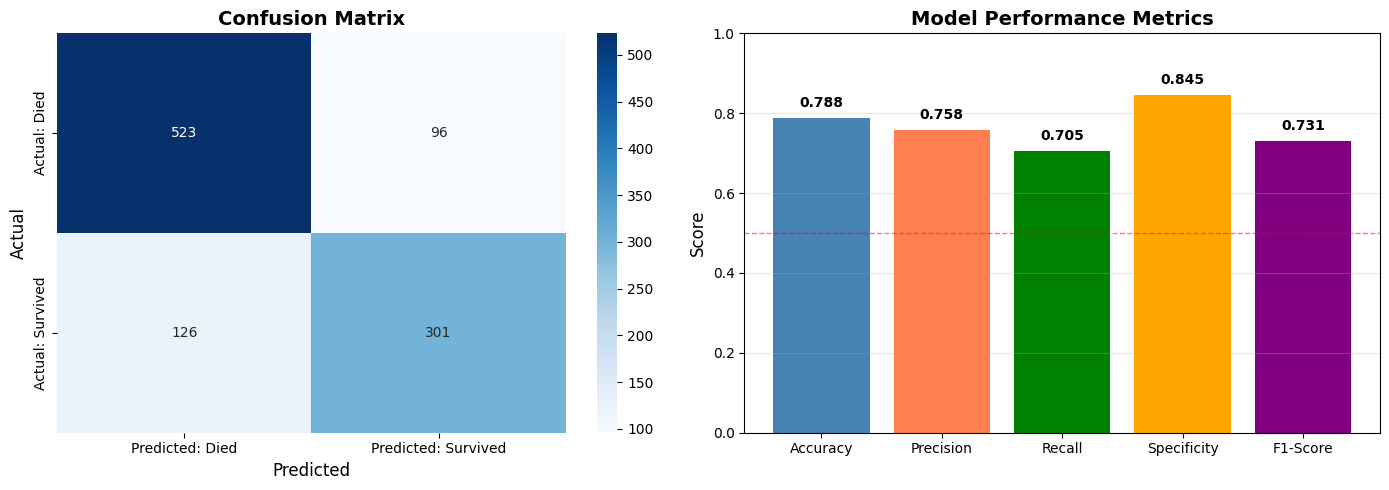

MODEL PERFORMANCE SUMMARY

Classification Accuracy: 0.7878 (78.78%)

Total Correct: 824 out of 1046 (78.8%)
Total Incorrect: 222 out of 1046 (21.2%)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
metrics_values = [accuracy, precision, recall, specificity, f1_score]

axes[1].bar(metrics_names, metrics_values, color=['steelblue', 'coral', 'green', 'orange', 'purple'])
axes[1].set_title('Model Performance Metrics', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)

for i, v in enumerate(metrics_values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"\nClassification Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nTotal Correct: {tp + tn} out of {len(y)} ({(tp+tn)/len(y)*100:.1f}%)")
print(f"Total Incorrect: {fp + fn} out of {len(y)} ({(fp+fn)/len(y)*100:.1f}%)")